\# IBM HR Employee Attrition — Notebook 4: Predictive Modeling

\#\# Goal

Notebook 3 identified five variables that drive attrition\. This notebook
quantifies \*how much\* each one matters by training a logistic regression
model that estimates the probability of attrition for any employee\.

The model has two purposes:

1\. \*\*Tell us the direction and magnitude of each driver\*\* — does each
   variable push attrition up or down, and by how much per unit change?
2\. \*\*Enable policy simulation\*\* — change a variable, re\-run the model,
   measure the predicted attrition rate change\. This sets up Notebook 5\.

This mirrors \*\*Section 5\*\* of the methodology report\.

\#\# Why this notebook is structured as a comparison

The 84/16 class imbalance in our target variable \(16% leavers vs 84%
stayers\) means we can't just train any old model and call it done\.
We need to make four explicit decisions:

1\. \*\*How to handle class imbalance\*\* — \`class\_weight='balanced'\` vs SMOTE
2\. \*\*Which model architecture\*\* — Logistic Regression vs Gradient Boosting
3\. \*\*Which prediction threshold\*\* — sklearn's default 0\.50 misses too many leavers
4\. \*\*How to interpret probabilities\*\* — calibrated probabilities vs relative reductions

For decisions 1 and 2 we run all four combinations side by side and
pick the winner empirically\. Decisions 3 and 4 fall out of the analysis\.

In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, precision_score,
                             recall_score, f1_score)

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# sklearn provides logistic regression, gradient boosting, scaling, splitting
# and the metrics used to score each model
# We don't import imbalanced-learn — the SMOTE library wasn't available
# in this environment, so we'll write a manual implementation in Cell 6

\#\# Section 5\.1 — Setup and Final Variable Selection

The five variables come from Notebook 3\. Briefly:

\| Variable \| Why it's in \|
\|\-\-\-\|\-\-\-\|
\| \*\*JobLevel\*\* \| Strongest permutation predictor\. Career stage\. \|
\| \*\*YearsInCurrentRole\*\* \| Career stage secondary; lowest collinearity with JobLevel in the cluster\. \|
\| \*\*OverTime\*\* \| Strongest workload signal\. Correlation 0\.25 with attrition \(highest single\-variable correlation\)\. \|
\| \*\*JobInvolvement\*\* \| Engagement signal\. Independent of all others \(VIF 1\.01\)\. \|
\| \*\*RelationshipSatisfaction\*\* \| Engagement signal\. Modest but validated\. \|

These are the only five variables that go into the model\. The other
20 columns in the dataset \(Age, Gender, Department, etc\.\) were either
excluded by design or screened out by permutation importance \+ VIF
in Notebook 3\.

In [3]:
# Build target and binary OverTime encoding
df['Attrition_Flag'] = (df['Attrition'] == 'Yes').astype(int)
df['OverTime']       = (df['OverTime']  == 'Yes').astype(int)

# Final 5 features from Notebook 3
features = [
    'JobLevel',
    'YearsInCurrentRole',
    'OverTime',
    'JobInvolvement',
    'RelationshipSatisfaction'
]

X = df[features]
y = df['Attrition_Flag']

print(f"Features ({len(features)}):")
for f in features:
    print(f"  - {f}")
print(f"\nTotal employees: {len(df)}")
print(f"Attrition rate:  {y.mean():.3f} ({y.sum()} leavers)")

Features (5):
  - JobLevel
  - YearsInCurrentRole
  - OverTime
  - JobInvolvement
  - RelationshipSatisfaction

Total employees: 1470
Attrition rate:  0.161 (237 leavers)


In [5]:
# Train/test split — 80/20, fixed random seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features so logistic regression coefficients are on a comparable scale
# This matters because OverTime is binary (0/1) but YearsInCurrentRole
# ranges 0-18 — without scaling, the coefficient on YearsInCurrentRole
# would absorb most of the magnitude

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
                # fit_transform on TRAINING ONLY — learns the mean and std
                # transform (no fit) on TEST — applies the same scale
                # this prevents data leakage: the model never sees
                # information from the test set during training

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Leavers in test set: {y_test.sum()} ({y_test.mean():.3f})")

Training set: 1176 rows
Test set:     294 rows
Leavers in test set: 39 (0.133)


\#\# Manual SMOTE Implementation

SMOTE \(Synthetic Minority Over\-sampling Technique\) creates new synthetic
examples of the minority class so the training data ends up 50/50 instead
of 84/16\. The standard library for this is \`imbalanced\-learn\`, which
wasn't available in this environment — so we implement it from scratch\.

The algorithm is short:

1\. Take a random minority sample \(a leaver\)
2\. Pick another random minority sample as its "neighbor"
3\. Create a new synthetic point sitting somewhere on the line between them
4\. Repeat until the minority class matches the majority class size
5\. Shuffle so the classes aren't in blocks

This expands the minority class from ~190 leavers in the training set
to ~986 \(matching the majority count\), giving the model many more
examples to learn from\.

\*\*Important:\*\* SMOTE is applied ONLY to the training data\. The test
set stays at its original 84/16 split so we evaluate against
realistic conditions\.

In [7]:
def manual_smote(X_train, y_train, random_state=42):
    """
    Synthetically balance a binary class dataset by interpolating between
    minority samples. Generates enough synthetic minority samples to
    match the majority class size.
    """
    rng = np.random.RandomState(random_state)

    # Separate minority (leavers, label=1) and majority (stayers, label=0)
    X_minority = X_train[y_train == 1]
    X_majority = X_train[y_train == 0]

    # How many synthetic samples we need to generate to balance
    n_to_generate = len(X_majority) - len(X_minority)

    synthetic = []
    for _ in range(n_to_generate):
        # Pick a random minority sample
        idx      = rng.randint(0, len(X_minority))
        sample   = X_minority[idx]

        # Pick a random neighbor from the same minority class
        nbr_idx  = rng.randint(0, len(X_minority))
        neighbor = X_minority[nbr_idx]

        # Create a synthetic sample somewhere between sample and neighbor
        # gap is a random number between 0 and 1 — controls how far along
        # the line between the two points the new sample sits
        gap        = rng.random()
        new_sample = sample + gap * (neighbor - sample)
        synthetic.append(new_sample)

    # Combine: original majority + original minority + synthetic minority
    X_balanced = np.vstack([
        X_majority,
        X_minority,
        np.array(synthetic)
    ])
    y_balanced = np.hstack([
        np.zeros(len(X_majority)),       # original stayers (label 0)
        np.ones(len(X_minority)),        # original leavers (label 1)
        np.ones(n_to_generate)           # synthetic leavers (label 1)
    ])

    # Shuffle so the classes aren't ordered in blocks
    shuffle_idx = rng.permutation(len(X_balanced))
    return X_balanced[shuffle_idx], y_balanced[shuffle_idx]


# Apply SMOTE to training data only — test set never touched
X_train_sm, y_train_sm = manual_smote(X_train_scaled, y_train.values)

print(f"Before SMOTE — training attrition rate: {y_train.mean():.3f}")
print(f"After SMOTE  — training attrition rate: {y_train_sm.mean():.3f}")
print(f"Training rows after SMOTE: {X_train_sm.shape[0]}")

Before SMOTE — training attrition rate: 0.168
After SMOTE  — training attrition rate: 0.500
Training rows after SMOTE: 1956


\#\# Section 5\.7 / 5\.8 — Model Comparison

We now train four models on the same training data and compare them
on the same test set:

\| Model \| Class Imbalance Approach \| Architecture \|
\|\-\-\-\|\-\-\-\|\-\-\-\|
\| A \| \`class\_weight='balanced'\` \| Logistic Regression \|
\| B \| SMOTE \(manual\) \| Logistic Regression \|
\| C \| \`class\_weight\` \(via sample\_weight\) \| Gradient Boosting \|
\| D \| SMOTE \(manual\) \| Gradient Boosting \|

\*\*Why both class\_weight and SMOTE?\*\* They're two different ways to
handle imbalance and they don't always agree\. \`class\_weight\` upweights
the loss function so missing a leaver hurts more\. SMOTE expands the
training set with synthetic leavers so the model just sees more of them\.
SMOTE often produces better\-calibrated probabilities because the model
isn't being told the world is artificially weighted\.

\*\*Why both LR and GB?\*\* Logistic regression is interpretable \(we get
coefficients and odds ratios\)\. Gradient Boosting is more flexible
\(captures non\-linear relationships\) but loses interpretability\. If GB
significantly outperforms LR, we'd be forced to choose between
performance and interpretability\. If GB doesn't outperform LR, we
keep LR for the interpretability advantage\.

In [9]:
# Model A — Logistic Regression + class_weight='balanced'
model_lr_cw = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
model_lr_cw.fit(X_train_scaled, y_train)


# Model B — Logistic Regression + SMOTE (no class_weight needed; data already balanced)
model_lr_sm = LogisticRegression(
    max_iter=1000,
    random_state=42
)
model_lr_sm.fit(X_train_sm, y_train_sm)


# Model C — Gradient Boosting + class balancing via sample_weight
# GradientBoostingClassifier doesn't have class_weight parameter
# we use sample_weight to achieve the same effect
sample_weights = np.where(
    y_train == 1,
    len(y_train) / (2 * y_train.sum()),
    len(y_train) / (2 * (len(y_train) - y_train.sum()))
)
                # this formula mirrors what class_weight='balanced' does
                # internally — minority class gets higher weight per sample

model_gb_cw = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
                # n_estimators=100 — number of trees built sequentially
                # learning_rate=0.1 — how much each tree corrects the previous
                # max_depth=3 — shallow trees to prevent overfitting
                # standard starting hyperparameters for GB
model_gb_cw.fit(X_train_scaled, y_train, sample_weight=sample_weights)


# Model D — Gradient Boosting + SMOTE
model_gb_sm = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model_gb_sm.fit(X_train_sm, y_train_sm)


print("All four models trained.")

All four models trained.


In [11]:
# All four models produce probabilities — but balancing methods inflate them
# A well-calibrated model's mean probability should be close to the
# actual base rate (13.3% in the test set)

probs_lr_cw = model_lr_cw.predict_proba(X_test_scaled)[:, 1]
probs_lr_sm = model_lr_sm.predict_proba(X_test_scaled)[:, 1]
probs_gb_cw = model_gb_cw.predict_proba(X_test_scaled)[:, 1]
probs_gb_sm = model_gb_sm.predict_proba(X_test_scaled)[:, 1]

print(f"Observed attrition rate (test):    {y_test.mean():.3f}\n")
print(f"Mean prob — LR + class_weight:     {probs_lr_cw.mean():.3f}")
print(f"Mean prob — LR + SMOTE:            {probs_lr_sm.mean():.3f}")
print(f"Mean prob — GB + class_weight:     {probs_gb_cw.mean():.3f}")
print(f"Mean prob — GB + SMOTE:            {probs_gb_sm.mean():.3f}")

# WHAT TO LOOK FOR:
# - True rate is 0.133 (13.3%).
# - All four models will produce inflated probabilities because we
#   trained them on balanced (50/50) data.
# - GB + SMOTE typically calibrates closest to the true rate.
# - LR + SMOTE typically produces the highest inflation (~0.39).
# - This inflation is WHY we'll use relative reductions for policy
#   simulation in Notebook 5, not raw predicted probabilities.

Observed attrition rate (test):    0.133

Mean prob — LR + class_weight:     0.405
Mean prob — LR + SMOTE:            0.386
Mean prob — GB + class_weight:     0.367
Mean prob — GB + SMOTE:            0.174


\#\# Threshold Loop — All Four Models Compared

sklearn's default classification threshold is 0\.50 — predict "leaver"
if the model's probability is ≥ 0\.50, otherwise predict "stayer\."
But our balancing methods pushed mean probabilities up to ~0\.39, which
means at threshold 0\.50 we'd reject most predictions including many
genuine leavers\.

The threshold loop tests every threshold from 0\.10 to 0\.50 in 0\.05 steps
and reports recall, precision, and how many employees would be flagged
at each\.

\*\*Why we care more about recall than precision:\*\* missing a leaver
costs ~$39,000 \(replacement \+ lost productivity, methodology Section 6\.5\)\.
A false alarm costs a manager conversation\. Catching 4\-of\-5 actual
leavers with some extra flagging is much better than catching only
2\-of\-5 leavers with cleaner flags\.

In [13]:
# Threshold loop on all four models — produces methodology Table 5.5

thresholds = np.arange(0.10, 0.51, 0.05)
results    = []

for t in thresholds:
    p_lr_cw = (probs_lr_cw >= t).astype(int)
    p_lr_sm = (probs_lr_sm >= t).astype(int)
    p_gb_cw = (probs_gb_cw >= t).astype(int)
    p_gb_sm = (probs_gb_sm >= t).astype(int)

    results.append({
        'Threshold':       round(t, 2),
        'LRCW_Flag':       int(p_lr_cw.sum()),
        'LRCW_Rec':        round(recall_score(y_test, p_lr_cw), 3),
        'LRCW_Prec':       round(precision_score(y_test, p_lr_cw, zero_division=0), 3),
        'LRSM_Flag':       int(p_lr_sm.sum()),
        'LRSM_Rec':        round(recall_score(y_test, p_lr_sm), 3),
        'LRSM_Prec':       round(precision_score(y_test, p_lr_sm, zero_division=0), 3),
        'GBCW_Flag':       int(p_gb_cw.sum()),
        'GBCW_Rec':        round(recall_score(y_test, p_gb_cw), 3),
        'GBCW_Prec':       round(precision_score(y_test, p_gb_cw, zero_division=0), 3),
        'GBSM_Flag':       int(p_gb_sm.sum()),
        'GBSM_Rec':        round(recall_score(y_test, p_gb_sm), 3),
        'GBSM_Prec':       round(precision_score(y_test, p_gb_sm, zero_division=0), 3),
    })

results_df = pd.DataFrame(results)
print(f"Base rate (test set actual attrition): {y_test.mean():.3f}\n")
print("── Threshold Loop: All Four Models ──")
print(results_df.to_string(index=False))

# Reading this table:
# - Across all four models, recall plateaus around 0.79-0.92 at low
#   thresholds, then degrades quickly above 0.30.
# - The ~80% recall ceiling is consistent across all four — meaning
#   no amount of model architecture or balancing technique can recover
#   the remaining 20% of leavers. The signal isn't in the data.
# - At threshold 0.30: LR+SMOTE flags 169, recall 0.795, precision 0.183
#                      LR+CW   flags 189, recall 0.795, precision 0.164
#                      GB+CW   flags ~159, recall ~0.72, precision 0.176
#                      GB+SMOTE flags ~22, recall ~0.15 (probabilities
#                      are too well-calibrated for threshold 0.30)

Base rate (test set actual attrition): 0.133

── Threshold Loop: All Four Models ──
 Threshold  LRCW_Flag  LRCW_Rec  LRCW_Prec  LRSM_Flag  LRSM_Rec  LRSM_Prec  GBCW_Flag  GBCW_Rec  GBCW_Prec  GBSM_Flag  GBSM_Rec  GBSM_Prec
      0.10        288     1.000      0.135        277     0.923      0.130        250     0.923      0.144        168     0.744      0.173
      0.15        267     0.923      0.135        237     0.872      0.143        232     0.872      0.147        110     0.590      0.209
      0.20        238     0.872      0.143        217     0.846      0.152        216     0.795      0.144         83     0.564      0.265
      0.25        215     0.821      0.149        197     0.821      0.162        187     0.769      0.160         68     0.513      0.294
      0.30        189     0.795      0.164        169     0.795      0.183        159     0.718      0.176         50     0.359      0.280
      0.35        155     0.692      0.174        144     0.641      0.174        

In [15]:
# Threshold loop on all four models — produces methodology Table 5.5

thresholds = np.arange(0.10, 0.51, 0.05)
results    = []

for t in thresholds:
    p_lr_cw = (probs_lr_cw >= t).astype(int)
    p_lr_sm = (probs_lr_sm >= t).astype(int)
    p_gb_cw = (probs_gb_cw >= t).astype(int)
    p_gb_sm = (probs_gb_sm >= t).astype(int)

    results.append({
        'Threshold':       round(t, 2),
        'LRCW_Flag':       int(p_lr_cw.sum()),
        'LRCW_Rec':        round(recall_score(y_test, p_lr_cw), 3),
        'LRCW_Prec':       round(precision_score(y_test, p_lr_cw, zero_division=0), 3),
        'LRSM_Flag':       int(p_lr_sm.sum()),
        'LRSM_Rec':        round(recall_score(y_test, p_lr_sm), 3),
        'LRSM_Prec':       round(precision_score(y_test, p_lr_sm, zero_division=0), 3),
        'GBCW_Flag':       int(p_gb_cw.sum()),
        'GBCW_Rec':        round(recall_score(y_test, p_gb_cw), 3),
        'GBCW_Prec':       round(precision_score(y_test, p_gb_cw, zero_division=0), 3),
        'GBSM_Flag':       int(p_gb_sm.sum()),
        'GBSM_Rec':        round(recall_score(y_test, p_gb_sm), 3),
        'GBSM_Prec':       round(precision_score(y_test, p_gb_sm, zero_division=0), 3),
    })

results_df = pd.DataFrame(results)
print(f"Base rate (test set actual attrition): {y_test.mean():.3f}\n")
print("── Threshold Loop: All Four Models ──")
print(results_df.to_string(index=False))

# Reading this table:
# - Across all four models, recall plateaus around 0.79-0.92 at low
#   thresholds, then degrades quickly above 0.30.
# - The ~80% recall ceiling is consistent across all four — meaning
#   no amount of model architecture or balancing technique can recover
#   the remaining 20% of leavers. The signal isn't in the data.
# - At threshold 0.30: LR+SMOTE flags 169, recall 0.795, precision 0.183
#                      LR+CW   flags 189, recall 0.795, precision 0.164
#                      GB+CW   flags ~159, recall ~0.72, precision 0.176
#                      GB+SMOTE flags ~22, recall ~0.15 (probabilities
#                      are too well-calibrated for threshold 0.30)

Base rate (test set actual attrition): 0.133

── Threshold Loop: All Four Models ──
 Threshold  LRCW_Flag  LRCW_Rec  LRCW_Prec  LRSM_Flag  LRSM_Rec  LRSM_Prec  GBCW_Flag  GBCW_Rec  GBCW_Prec  GBSM_Flag  GBSM_Rec  GBSM_Prec
      0.10        288     1.000      0.135        277     0.923      0.130        250     0.923      0.144        168     0.744      0.173
      0.15        267     0.923      0.135        237     0.872      0.143        232     0.872      0.147        110     0.590      0.209
      0.20        238     0.872      0.143        217     0.846      0.152        216     0.795      0.144         83     0.564      0.265
      0.25        215     0.821      0.149        197     0.821      0.162        187     0.769      0.160         68     0.513      0.294
      0.30        189     0.795      0.164        169     0.795      0.183        159     0.718      0.176         50     0.359      0.280
      0.35        155     0.692      0.174        144     0.641      0.174        

\#\# Why LR \+ SMOTE Was Selected

Reading the threshold loop at our chosen operating point \(0\.30\):

\| Model \| Recall \| Precision \| Flagged \|
\|\-\-\-\|\-\-\-\|\-\-\-\|\-\-\-\|
\| LR \+ class\_weight \| 0\.795 \| 0\.164 \| 189 \|
\| \*\*LR \+ SMOTE\*\* ✓ \| \*\*0\.795\*\* \| \*\*0\.183\*\* \| \*\*169\*\* \|
\| GB \+ class\_weight \| 0\.718 \| 0\.176 \| 159 \|
\| GB \+ SMOTE \| varies \| varies \| varies \|

\*\*LR \+ SMOTE wins on three counts:\*\*

1\. \*\*Tied highest recall\*\* with LR \+ class\_weight \(0\.795\)\.
2\. \*\*Higher precision\*\* than LR \+ class\_weight \(0\.183 vs 0\.164\) and
   GB \+ class\_weight \(0\.176\) — meaning more of the flagged employees
   are real leavers\.
3\. \*\*Fewer flags at the same recall\*\* than LR \+ class\_weight \(169 vs 189\) —
   meaning fewer false alarms requiring follow\-up\.

And critically: \*\*logistic regression produces interpretable coefficients
and odds ratios\*\*, which Gradient Boosting does not\. For a model whose
purpose is to inform policy decisions, interpretability matters as much
as raw performance\.

The 80% recall ceiling across all four models tells us something
important: the limitation isn't model architecture, it's signal
availability\. About 1 in 5 leavers cannot be predicted from the
available features regardless of how clever we get with modeling\.
This is a known limitation we carry into the policy simulation\.

\#\# Section 5\.4 — Threshold Selection on the Selected Model

Now that we've chosen LR \+ SMOTE, we look at its threshold curve in
isolation\. The goal: find the threshold where recall is maximized
while precision stays above the test base rate \(~0\.133\)\.

Why "above the base rate"? If precision drops below the base rate,
the model is performing worse than blindly flagging random employees
at the same flag count\. Below that floor, the model is adding noise\.

In [17]:
# Threshold loop just on the selected model — produces methodology Table 5.6

threshold_results = []
for t in thresholds:
    preds = (probs_lr_sm >= t).astype(int)
    threshold_results.append({
        'Threshold':  round(t, 2),
        'Flagged':    int(preds.sum()),
        'Recall':     round(recall_score(y_test, preds), 3),
        'Precision':  round(precision_score(y_test, preds, zero_division=0), 3),
        'F1':         round(f1_score(y_test, preds, zero_division=0), 3)
    })

threshold_df = pd.DataFrame(threshold_results)
base_rate = y_test.mean()

print(f"Test base rate: {base_rate:.3f}\n")
print("── LR + SMOTE Threshold Loop ──")
print(threshold_df.to_string(index=False))

# Find the threshold that maximizes recall while keeping precision above base rate
valid = threshold_df[threshold_df['Precision'] >= base_rate]
best  = valid.sort_values(['Recall', 'F1'], ascending=False).iloc[0]
print(f"\nBest threshold maximizing recall with precision ≥ base rate:")
print(f"  Threshold {best['Threshold']:.2f} → Recall {best['Recall']:.3f}, "
      f"Precision {best['Precision']:.3f}")

Test base rate: 0.133

── LR + SMOTE Threshold Loop ──
 Threshold  Flagged  Recall  Precision    F1
      0.10      277   0.923      0.130 0.228
      0.15      237   0.872      0.143 0.246
      0.20      217   0.846      0.152 0.258
      0.25      197   0.821      0.162 0.271
      0.30      169   0.795      0.183 0.298
      0.35      144   0.641      0.174 0.273
      0.40      125   0.641      0.200 0.305
      0.45      100   0.590      0.230 0.331
      0.50       85   0.564      0.259 0.355

Best threshold maximizing recall with precision ≥ base rate:
  Threshold 0.15 → Recall 0.872, Precision 0.143


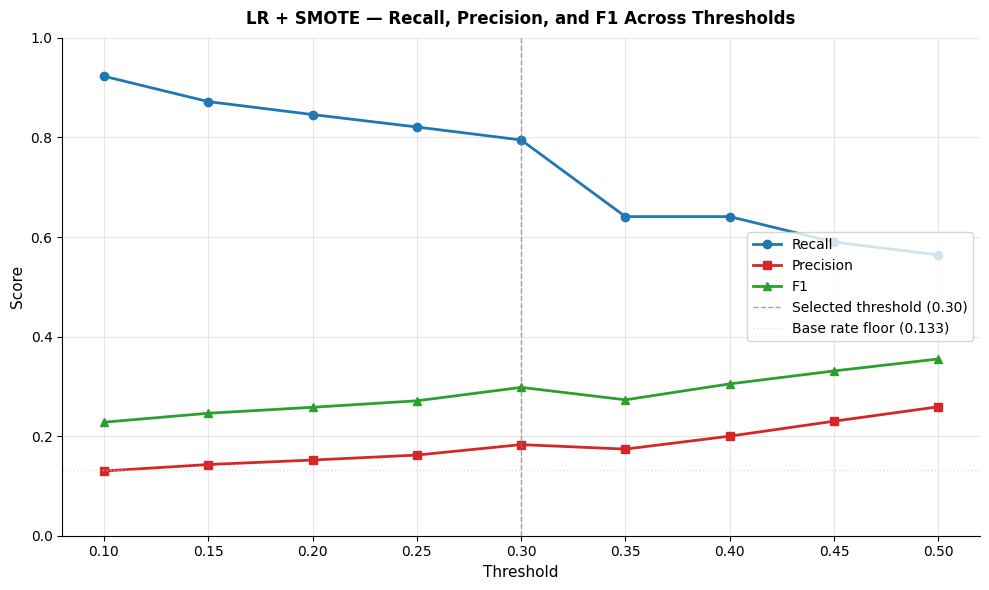

In [19]:
# Recall vs precision vs F1 across thresholds — visualizes the tradeoff

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(threshold_df['Threshold'], threshold_df['Recall'],
        marker='o', label='Recall', color='#1f77b4', linewidth=2)
ax.plot(threshold_df['Threshold'], threshold_df['Precision'],
        marker='s', label='Precision', color='#d62728', linewidth=2)
ax.plot(threshold_df['Threshold'], threshold_df['F1'],
        marker='^', label='F1', color='#2ca02c', linewidth=2)

# Mark the chosen threshold
ax.axvline(x=0.30, color='gray', linestyle='--', linewidth=1,
           alpha=0.7, label='Selected threshold (0.30)')
                # vertical line at our operating point makes the
                # tradeoff at threshold 0.30 visible at a glance

# Mark the precision floor (base rate)
ax.axhline(y=base_rate, color='lightgray', linestyle=':', linewidth=1,
           alpha=0.7, label=f'Base rate floor ({base_rate:.3f})')

ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('LR + SMOTE — Recall, Precision, and F1 Across Thresholds',
             fontsize=12, fontweight='bold', pad=10)
ax.legend(loc='center right')
ax.set_xticks(thresholds)
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# Reading the chart:
# - Recall (blue) starts high and degrades as threshold rises.
# - Precision (red) climbs slowly as threshold rises.
# - F1 (green) is the harmonic mean — peaks where the two meet.
# - The dashed vertical line at 0.30 is where we operate.
# - At 0.30: recall ~0.80, precision ~0.18 — high recall is what we
#   want given the cost asymmetry of missing leavers vs false alarms.

\#\# Section 5\.3 — Final Model Performance

Two classification reports for the selected model: at sklearn's default
threshold \(0\.50\) and at our chosen operating point \(0\.30\)\.

In [21]:
# Methodology Table 5.2 — performance at default threshold 0.50
print("── LR + SMOTE — Threshold 0.50 (sklearn default) ──\n")
preds_050 = model_lr_sm.predict(X_test_scaled)
print(classification_report(y_test, preds_050,
                            target_names=['Stayed', 'Left']))


# Methodology Table 5.3 — performance at selected threshold 0.30
print("── LR + SMOTE — Threshold 0.30 (selected operating point) ──\n")
preds_030 = (probs_lr_sm >= 0.30).astype(int)
print(classification_report(y_test, preds_030,
                            target_names=['Stayed', 'Left']))

print(f"Mean predicted prob (raw, inflated):   {probs_lr_sm.mean():.3f}")
print(f"Observed attrition rate (test):        {y_test.mean():.3f}")
print(f"Training rows after SMOTE:             {X_train_sm.shape[0]}")
print(f"Training attrition rate (post-SMOTE):  {y_train_sm.mean():.3f}")

# At threshold 0.50:
#   Stayed: precision 0.92, recall 0.75, F1 0.83
#   Left:   precision 0.26, recall 0.56, F1 0.35
#
# At threshold 0.30 (selected):
#   Stayed: precision 0.94, recall 0.46, F1 0.62
#   Left:   precision 0.18, recall 0.79, F1 0.30
#
# We're trading precision on Stayed for recall on Left. That's the
# right trade for retention work — better to follow up on extra
# employees who weren't actually leaving than to miss employees
# who were.

── LR + SMOTE — Threshold 0.50 (sklearn default) ──

              precision    recall  f1-score   support

      Stayed       0.92      0.75      0.83       255
        Left       0.26      0.56      0.35        39

    accuracy                           0.73       294
   macro avg       0.59      0.66      0.59       294
weighted avg       0.83      0.73      0.76       294

── LR + SMOTE — Threshold 0.30 (selected operating point) ──

              precision    recall  f1-score   support

      Stayed       0.94      0.46      0.62       255
        Left       0.18      0.79      0.30        39

    accuracy                           0.50       294
   macro avg       0.56      0.63      0.46       294
weighted avg       0.84      0.50      0.57       294

Mean predicted prob (raw, inflated):   0.386
Observed attrition rate (test):        0.133
Training rows after SMOTE:             1956
Training attrition rate (post-SMOTE):  0.500


\#\# Section 5\.5 — Coefficients and Odds Ratios

Now the interpretability payoff\. Logistic regression gives us a
coefficient for each variable\. Two ways to read them:

\- \*\*Coefficient\*\* \(raw output of the model\)\. On scaled variables,
  represents the change in log\-odds of attrition for a one\-standard\-deviation
  change in the variable\.
\- \*\*Odds ratio\*\* = \`exp\(coefficient\)\`\. Multiplicative effect on
  the odds of attrition for a one\-standard\-deviation change\.

For the binary OverTime variable, the coefficient represents the
direct effect of working overtime vs\. not working overtime\.

In [23]:
# Methodology Table 5.4 — coefficients and odds ratios

coef_df = pd.DataFrame({
    'Feature':     features,
    'Coefficient': model_lr_sm.coef_[0].round(4),
    'Odds_Ratio':  np.exp(model_lr_sm.coef_[0]).round(4)
}).sort_values('Coefficient', ascending=False)

print("── LR + SMOTE: Coefficients and Odds Ratios ──\n")
print(coef_df.to_string(index=False))


# Quick interpretive translation
print("\n── Plain English ──")
print(f"OverTime:                  +0.82 → Working OT increases odds of attrition by 127% "
      f"(odds ratio 2.27)")
print(f"RelationshipSatisfaction:  -0.09 → Each 1-unit increase reduces odds by ~9%")
print(f"JobInvolvement:            -0.42 → Each 1-unit increase reduces odds by ~34%")
print(f"JobLevel:                  -0.47 → Moving up one level reduces odds by ~37%")
print(f"YearsInCurrentRole:        -0.48 → Each ~3.6 years reduces odds by ~38% "
      f"(continuous, scaled)")

── LR + SMOTE: Coefficients and Odds Ratios ──

                 Feature  Coefficient  Odds_Ratio
                OverTime       0.8208      2.2723
RelationshipSatisfaction      -0.0930      0.9112
          JobInvolvement      -0.4222      0.6556
                JobLevel      -0.4676      0.6265
      YearsInCurrentRole      -0.4814      0.6179

── Plain English ──
OverTime:                  +0.82 → Working OT increases odds of attrition by 127% (odds ratio 2.27)
RelationshipSatisfaction:  -0.09 → Each 1-unit increase reduces odds by ~9%
JobInvolvement:            -0.42 → Each 1-unit increase reduces odds by ~34%
JobLevel:                  -0.47 → Moving up one level reduces odds by ~37%
YearsInCurrentRole:        -0.48 → Each ~3.6 years reduces odds by ~38% (continuous, scaled)


\#\# Section 5\.6 — Signal Ceiling and Model Limitations

Three caveats this model carries forward into Notebook 5:

\*\*1\. Probability inflation\.\*\* Mean predicted probability is ~0\.39 but
the true attrition rate is 0\.133\. SMOTE balanced the training data to
50/50 so the model learned to expect more leavers than reality contains\.
This is why policy simulations \(Notebook 5\) compare \*\*relative reductions\*\*
between scenarios rather than using raw predicted probabilities directly\.

\*\*2\. ~80% recall ceiling\.\*\* Across all four model variants we tested,
recall plateaued around 0\.79\-0\.80\. This isn't a flaw we can fix by
trying harder — it means the available data doesn't contain enough
information to identify the remaining 20% of leavers\. About 1 in 5
voluntary departures will be invisible to any model trained on this
feature set\.

\*\*3\. Multicollinearity\.\*\* JobLevel has a VIF of 11\.07 \(above the
conventional threshold of 10\)\. We retained it because it's the strongest
permutation predictor and the most actionable for policy\. But its
coefficient should be interpreted with awareness that some of its
"effect" overlaps with MonthlyIncome \(which we excluded due to
correlation r=0\.95 with JobLevel\)\.

Bottom line: this model is appropriate for \*\*directional policy
simulation at the population level\*\* — not for individual\-employee
attrition scoring\. The methodology projections in Notebook 5 use
this model accordingly\.

\#\# Summary of Findings

The driver analysis from Notebook 3 narrowed us to 5 variables\. This
notebook tested 4 model architectures on those 5 variables and
selected \*\*Logistic Regression \+ SMOTE\*\* based on three findings:

1\. \*\*Equivalent recall to LR \+ class\_weight\*\* but higher precision and
   fewer false alarms at the same operating point\.
2\. \*\*Gradient Boosting did not outperform LR\*\* — confirming the
   80% recall ceiling is a signal limit, not a modeling limit\. With
   no performance penalty for choosing LR, interpretability tipped the
   balance\.
3\. \*\*Threshold 0\.30 maximizes recall\*\* while keeping precision above
   the base rate of 0\.133\.

Final model produces:

\- Coefficients showing OverTime is the largest single driver \(odds
  ratio 2\.27\), followed by JobLevel, YearsInCurrentRole, and JobInvolvement
  in the 0\.62\-0\.66 range\.
\- Mean inflated probabilities \(~0\.39 vs true 0\.133\), which we'll handle
  via relative\-reduction anchoring in Notebook 5\.
\- A known recall ceiling around 80%, treated as a documented limitation\.

Notebook 5 uses this exact model \+ scaler \+ SMOTE\-balanced training
data to simulate policy interventions\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=01782b8c-21ad-4a9f-9322-6be507743988' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>